In [15]:
#2. Location Analysis 

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

In [58]:
df = pd.read_csv('disaster_train.csv')
df = df[df['location'].notna()]
df['location']

31                                             Birmingham
32                          Est. September 2012 - Bristol
33                                                 AFRICA
34                                       Philadelphia, PA
35                                             London, UK
36                                               Pretoria
37                                           World Wide!!
39                                         Paranaque City
40                                         Live On Webcam
42                                              milky way
46                              GREENSBORO,NORTH CAROLINA
48                                         Live On Webcam
49                                               England.
50                               Sheffield Township, Ohio
51                                                  India
52                                               Barbados
53                                                Anaheim
54            

In [63]:
df['location'] = df['location'].str.strip().str.lower().str.title()
df['location'] = df['location'].str.replace('[^a-zA-Z ]','',regex=True)
df['location'] = df['location'].str.split(',').str[0]
df['location'] = df['location'].replace({
    "Usa" : "United States",
    "Uk" : "United Kingdom",
    "Nyc" : "New York",
    "Us" : "United States",
    "New York City" : "New York",
    "Ny" : "New York",
    "New York Ny" : "New York"
})
df = df[df['location'].str.strip() != '']
df = df[~df['location'].str.contains(
    r'\b(?:world|ss|webcam|global|earth|worldwide)\b',case=False,na=False
)]

In [64]:
df['location']

31                                        Birmingham
32                           Est September   Bristol
33                                            Africa
34                                   Philadelphia Pa
35                                         London Uk
36                                          Pretoria
39                                    Paranaque City
42                                         Milky Way
46                          Greensboronorth Carolina
49                                           England
50                           Sheffield Township Ohio
51                                             India
52                                          Barbados
53                                           Anaheim
54                                             Abuja
55                                     United States
56                                      South Africa
57                                  Sao Paulo Brazil
58                                     Hollywo

In [65]:
location_count = df['location'].value_counts()

pd.set_option('display.max_rows',None)


In [66]:
location_count.head(80)

location
United States                    172
New York                         128
London                            51
United Kingdom                    46
Washington Dc                     43
Nigeria                           35
Canada                            35
India                             28
Los Angeles Ca                    28
Mumbai                            24
Chicago Il                        22
California                        21
Kenya                             21
T                                 20
Everywhere                        20
Australia                         19
Los Angeles                       16
California Usa                    15
San Francisco                     14
Chicago                           14
Indonesia                         14
Florida                           14
Texas                             14
Toronto                           13
London Uk                         13
Atlanta Ga                        12
Ireland                      

Text(0, 0.5, 'Number of posts ')

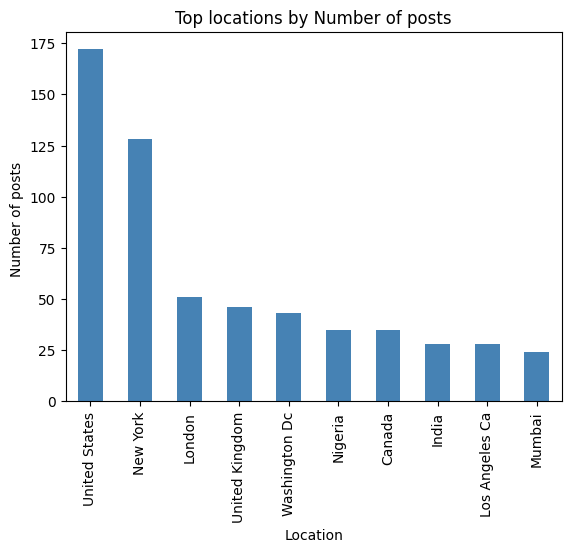

In [67]:
location_count.head(10).plot(kind='bar',color='steelblue')
plt.title('Top locations by Number of posts')
plt.xlabel('Location')
plt.ylabel('Number of posts ')